### Info

this is the github page of this HW : https://github.com/kiarashrahmani/LLMs-TMU-Spring2026

# Word2vec from scratch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import collections
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import urllib.request
import zipfile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Loading data and preprocess

In [7]:
import zipfile
import re

# Open the local zip file
with zipfile.ZipFile("text8.zip") as f:
    text = f.read(f.namelist()[0]).decode('utf-8')

# Tokenize & Preprocess
def preprocess(text):
    text = text.lower()
    # Find all alphanumeric sequences (removes punctuation)
    tokens = re.findall(r'\w+', text)
    return tokens

tokens = preprocess(text)
print(f"Total tokens: {len(tokens)}")


Total tokens: 17005207


In [8]:
print("--- Preprocessing Sample ---")
print(f"First 20 tokens: {tokens[:20]}")
print(f"\nMiddle slice (tokens 500-510): {tokens[500:510]}")

# Vocab statistics
vocab = set(tokens)
print(f"\n--- Statistics ---")
print(f"Total tokens in corpus: {len(tokens):,}")
print(f"Unique words (Vocab size): {len(vocab):,}")

# Join a small sample back into a string to see how it looks
print(f"\nReconstructed string snippet: {' '.join(tokens[100:115])}")


--- Preprocessing Sample ---
First 20 tokens: ['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']

Middle slice (tokens 500-510): ['in', 'the', 'thick', 'of', 'the', 'french', 'revolution', 'william', 'godwin', 'published']

--- Statistics ---
Total tokens in corpus: 17,005,207
Unique words (Vocab size): 253,854

Reconstructed string snippet: interpretations of what this means anarchism also refers to related social movements that advocate the


Total Unique Words: 253854
Words appearing only once: 118519
Words appearing 5 or more times: 71290


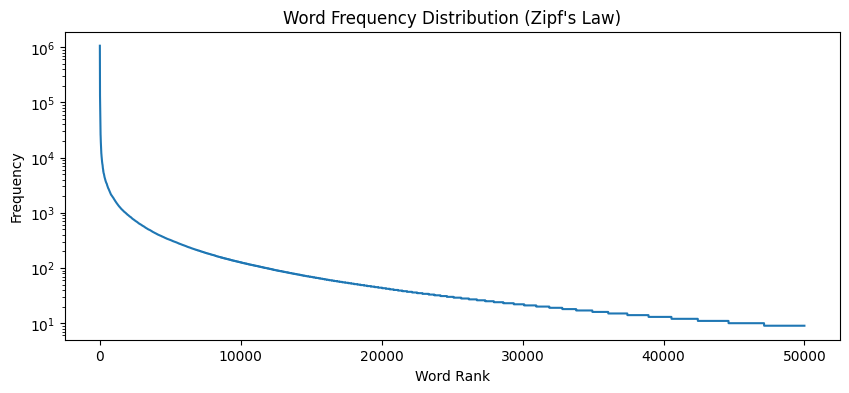

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

# Count word frequencies
word_counts = Counter(tokens)
sorted_counts = sorted(word_counts.values(), reverse=True)

# statistics
print(f"Total Unique Words: {len(word_counts)}")
print(f"Words appearing only once: {len([w for w in word_counts if word_counts[w] == 1])}")
print(f"Words appearing 5 or more times: {len([w for w in word_counts if word_counts[w] >= 5])}")

# Visualize the Long Tail
plt.figure(figsize=(10, 4))
plt.plot(sorted_counts[:50000])
plt.title("Word Frequency Distribution (Zipf's Law)")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")
plt.yscale('log') 
plt.show()


In [11]:
import numpy as np

total_count = len(tokens)


counts = [count for word, count in word_counts.most_common()]
cumulative_coverage = np.cumsum(counts) / total_count


for percent in [0.80, 0.90, 0.95, 0.99]:
    vocab_needed = np.searchsorted(cumulative_coverage, percent)
    print(f"{int(percent*100)}% coverage requires top {vocab_needed:,} words")


80% coverage requires top 3,354 words
90% coverage requires top 10,296 words
95% coverage requires top 23,924 words
99% coverage requires top 109,568 words


In [14]:
# Used by org paper itself
min_freq = 5
words_above_min = [word for word, count in word_counts.items() if count >= min_freq]
print(f"Words appearing {min_freq}+ times: {len(words_above_min):,}")

Words appearing 5+ times: 71,290


## Building Vocabulary

In [15]:
VOCAB_SIZE = 20000
UNK_TOKEN = "<UNK>"

def build_vocab(tokens, vocab_size):

    word_counts = collections.Counter(tokens)
    # TOP 20k words
    top_words = word_counts.most_common(vocab_size - 1)
    
    vocab = {word: i for i, (word, _) in enumerate(top_words)}
    vocab[UNK_TOKEN] = vocab_size - 1
    
    # id to word mapping
    id_to_word = {i: word for word, i in vocab.items()}
    
    # replacing unknown with UNK
    data = [vocab.get(word, vocab[UNK_TOKEN]) for word in tokens]
    
    return data, vocab, id_to_word, word_counts

data, vocab, id_to_word, word_counts = build_vocab(tokens, VOCAB_SIZE)
print(f"Vocab size: {len(vocab)}")
print(f"Sample data (first 10 IDs): {data[:10]}")


Vocab size: 20000
Sample data (first 10 IDs): [5233, 3080, 11, 5, 194, 1, 3133, 45, 58, 155]


## Dataset (Generating Training tuples)

In [17]:
class Word2VecDataset(Dataset):
    def __init__(self, data, vocab_size, window_size=2, k_neg=5):
        self.data = data
        self.vocab_size = vocab_size
        self.window_size = window_size
        self.k_neg = k_neg
        
       # Negative Smapling 3/4 is common 
        word_counts = collections.Counter(data)
        freqs = np.array([word_counts.get(i, 0) for i in range(vocab_size)])
        unigram_dist = freqs**0.75 / np.sum(freqs**0.75)
        self.unigram_dist = torch.from_numpy(unigram_dist)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        center_word = self.data[idx]
        # Context Window
        start = max(0, idx - self.window_size)
        end = min(len(self.data), idx + self.window_size + 1)
        
        # Random Word from CW
        context_idx = np.random.choice([i for i in range(start, end) if i != idx])
        pos_context = self.data[context_idx]
        
        # Negative sampling
        neg_contexts = torch.multinomial(self.unigram_dist, self.k_neg, replacement=True)
        
        return center_word, pos_context, neg_contexts

dataset = Word2VecDataset(data, VOCAB_SIZE)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

## SGNS Arch

In [18]:
class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SkipGramNegativeSampling, self).__init__()
        self.target_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)
        
        initrange = 0.5 / embed_dim
        self.target_embeddings.weight.data.uniform_(-initrange, initrange)
        self.context_embeddings.weight.data.uniform_(0, 0)

    def forward(self, center_words, pos_words, neg_words):
        # center_words: [batch_size]
        # pos_words: [batch_size]
        # neg_words: [batch_size, k_neg]

        emb_center = self.target_embeddings(center_words)    # [B, d]
        emb_pos = self.context_embeddings(pos_words)        # [B, d]
        emb_neg = self.context_embeddings(neg_words)        # [B, K, d]

        pos_score = torch.sum(emb_center * emb_pos, dim=1)  # [B]
        pos_loss = F.logsigmoid(pos_score)

    
        neg_score = torch.bmm(emb_neg, emb_center.unsqueeze(2)).squeeze(2) # [B, K]
        neg_loss = torch.sum(F.logsigmoid(-neg_score), dim=1) # [B]

        return -(pos_loss + neg_loss).mean()

EMBED_DIM = 100
model = SkipGramNegativeSampling(VOCAB_SIZE, EMBED_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training Loop

In [20]:
from tqdm import tqdm  

EPOCHS = 3
losses = []

print("Starting Training...")
for epoch in range(EPOCHS):
    total_loss = 0
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch")
    
    for center, pos, neg in progress_bar:
        center, pos, neg = center.to(device), pos.to(device), neg.to(device)
        
        optimizer.zero_grad()
        loss = model(center, pos, neg)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        current_loss = loss.item()
        
        progress_bar.set_postfix(loss=f"{current_loss:.4f}")
            
    avg_loss = total_loss / len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1} completed. Average Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "word2vec_sgns.pth")


Starting Training...


Epoch 1/3: 100%|██████████| 16607/16607 [1:26:46<00:00,  3.19batch/s, loss=2.2308]  


Epoch 1 completed. Average Loss: 2.2544


Epoch 2/3: 100%|██████████| 16607/16607 [1:07:21<00:00,  4.11batch/s, loss=2.1934]


Epoch 2 completed. Average Loss: 2.1703


Epoch 3/3: 100%|██████████| 16607/16607 [1:10:19<00:00,  3.94batch/s, loss=2.1166]

Epoch 3 completed. Average Loss: 2.1420


In [21]:
def find_most_similar(target_word, model, vocab, id_to_word, top_k=5):
    if target_word not in vocab:
        return "Word not in vocab"
    
    target_idx = torch.tensor([vocab[target_word]]).to(device)
    target_vec = model.target_embeddings(target_idx) 
    
    all_vectors = model.target_embeddings.weight 
    
    sim = F.cosine_similarity(target_vec, all_vectors) 
    
    values, indices = torch.topk(sim, top_k + 1)
    
    print(f"Words similar to '{target_word}':")
    for i in range(1, len(indices)): 
        print(f"{id_to_word[indices[i].item()]}: {values[i].item():.4f}")

find_most_similar("king", model, vocab, id_to_word)

Words similar to 'king':
queen: 0.7747
elector: 0.7511
prince: 0.7430
pope: 0.7273
patriarch: 0.6965


# Plots

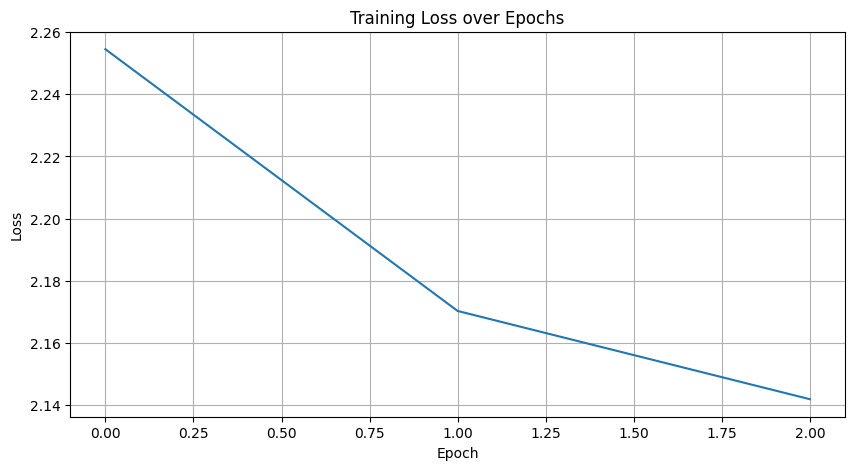

Vector for 'apple' (first 10 dims): [-0.2977084  -0.05728412 -0.26180726  0.03551932  0.30671877 -0.3509315
 -0.6846067  -0.6413886  -0.55903286  0.12995175]


In [22]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

word_vectors = model.target_embeddings.weight.data.cpu().numpy()

def get_vector(word):
    if word in vocab:
        idx = vocab[word]
        return word_vectors[idx]
    return None

example_vec = get_vector('apple')
print(f"Vector for 'apple' (first 10 dims): {example_vec[:10] if example_vec is not None else 'Not in vocab'}")

# Test usage

In [ ]:
from sklearn.decomposition import PCA
import torch.nn.functional as F

def analyze_words(word1, word2, model, vocab, id_to_word):
    model.eval() 
    
    if word1 not in vocab or word2 not in vocab:
        return "یکی از کلمات در واژگان (Vocab) یافت نشد."

    idx1 = torch.tensor([vocab[word1]]).to(device)
    idx2 = torch.tensor([vocab[word2]]).to(device)
    
    with torch.no_grad():
        vec1 = model.target_embeddings(idx1)
        vec2 = model.target_embeddings(idx2)


    similarity = F.cosine_similarity(vec1, vec2).item()
    
    print(f"Vector for '{word1}' (first 5 dims): {vec1.cpu().numpy()[0][:5]}")
    print(f"Vector for '{word2}' (first 5 dims): {vec2.cpu().numpy()[0][:5]}")
    print(f"--- Similarity: {similarity:.4f} ---")


    random_words = [id_to_word[np.random.randint(0, 1000)] for _ in range(5)]
    all_words = [word1, word2] + random_words
    all_indices = torch.tensor([vocab[w] for w in all_words]).to(device)
    
    with torch.no_grad():
        all_vectors = model.target_embeddings(all_indices).cpu().numpy()

    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(all_vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='blue', edgecolors='k')

    for i, word in enumerate(all_words):
        color = 'red' if word in [word1, word2] else 'black'
        plt.annotate(word, (vectors_2d[i, 0]+0.01, vectors_2d[i, 1]+0.01), 
                     fontsize=12, color=color, fontweight='bold' if color=='red' else 'normal')

    plt.title(f"Visualizing Similarity: {word1} vs {word2}")
    plt.grid(True)
    plt.show()

w1 = input("Enter first word: ").lower()
w2 = input("Enter second word: ").lower()
analyze_words(w1, w2, model, vocab, id_to_word)

# Part 2 

In [13]:
from gensim.models import KeyedVectors

glove_input_file = 'glove6B/glove.6B.100d.txt'


glove_model = KeyedVectors.load_word2vec_format(glove_input_file, binary=False, no_header=True)

print(f"GloVe model loaded successfully")
print(f"Vocabulary size: {len(glove_model.index_to_key)}")
print(f"Vector dimension: {glove_model.vector_size}")

print("Similarity between 'computer' and 'software':", glove_model.similarity('computer', 'software'))

GloVe model loaded successfully
Vocabulary size: 400000
Vector dimension: 100
Similarity between 'computer' and 'software': 0.8373122


## Part 3

In [10]:
import numpy as np

def cosine_similarity(A, B):
    # Manual implementation of cosine similarity calculation
    return np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

def find_k_nearest(target_word, model, k=5):
    if target_word not in model: return "Word not in vocabulary"
    
    target_vec = model[target_word]
    results = []
    
    for word in model.index_to_key:
        if word == target_word: continue
        sim = cosine_similarity(target_vec, model[word])
        results.append((word, sim))
    
    return sorted(results, key=lambda x: x[1], reverse=True)[:k]

for w in ['apple', 'car', 'intelligence', 'python']:
    print(f"Nearest to {w}:", find_k_nearest(w, glove_model))

def solve_analogy(a, b, c, model):
    vec = model[b] - model[a] + model[c]
    
    max_sim = -1
    best_word = None
    
    for word in model.index_to_key:
        if word in [a, b, c]: continue
        sim = cosine_similarity(vec, model[word])
        if sim > max_sim:
            max_sim = sim
            best_word = word
    return best_word

# Analogy tests
print("Man:King :: Woman:", solve_analogy('man', 'king', 'woman', glove_model))
print("Man:Doctor :: Woman:", solve_analogy('man', 'doctor', 'woman', glove_model))


Nearest to apple: [('microsoft', 0.7449405), ('ibm', 0.6821643), ('intel', 0.6778089), ('software', 0.6775422), ('dell', 0.6741441)]
Nearest to car: [('vehicle', 0.86308384), ('truck', 0.8597878), ('cars', 0.83716697), ('driver', 0.818591), ('driving', 0.7812636)]
Nearest to intelligence: [('cia', 0.74218047), ('information', 0.7210197), ('security', 0.69631016), ('fbi', 0.696229), ('military', 0.6934822)]
Nearest to python: [('monty', 0.6886237), ('php', 0.5865386), ('perl', 0.57844085), ('cleese', 0.5446676), ('flipper', 0.5112984)]
Man:King :: Woman: queen
Man:Doctor :: Woman: nurse


## part 4

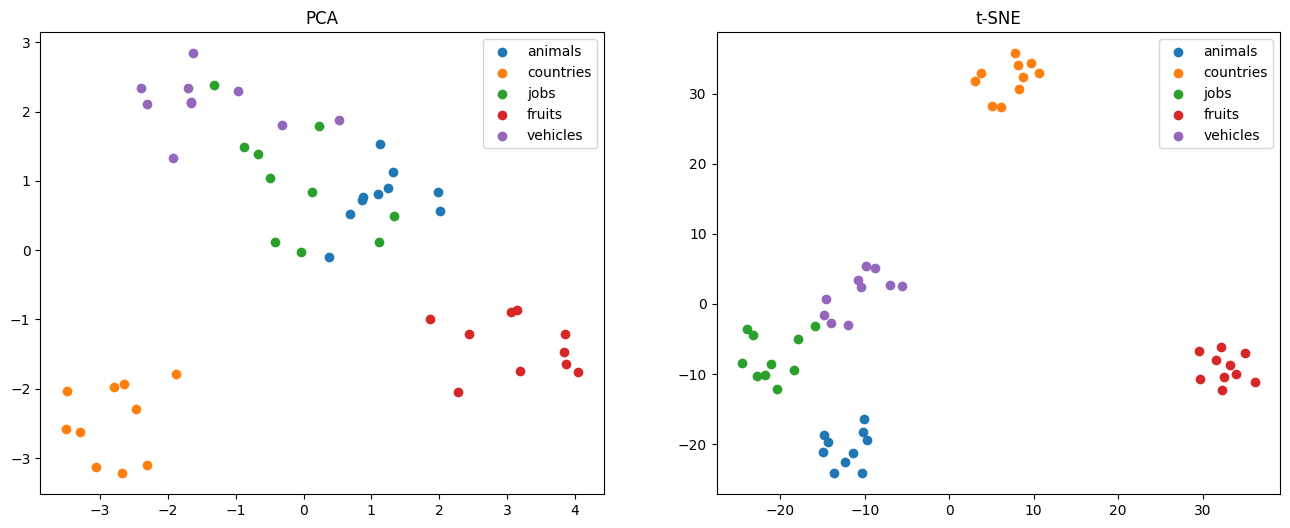

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

categories = {
    'animals': ['lion', 'tiger', 'elephant', 'dog', 'cat', 'wolf', 'rabbit', 'deer', 'bear', 'fox'],
    'countries': ['iran', 'germany', 'france', 'japan', 'china', 'italy', 'brazil', 'canada', 'spain', 'egypt'],
    'jobs': ['doctor', 'engineer', 'teacher', 'nurse', 'artist', 'lawyer', 'chef', 'pilot', 'actor', 'farmer'],
    'fruits': ['apple', 'banana', 'orange', 'grape', 'strawberry', 'mango', 'lemon', 'cherry', 'pear', 'peach'],
    'vehicles': ['car', 'bus', 'train', 'plane', 'bike', 'truck', 'ship', 'rocket', 'helicopter', 'scooter']
}

data, labels, words = [], [], []
for cat, w_list in categories.items():
    for w in w_list:
        if w in glove_model:
            data.append(glove_model[w])
            labels.append(cat)
            words.append(w)

data = np.array(data)

# Dimensionality reduction
pca_data = PCA(n_components=2).fit_transform(data)
tsne_data = TSNE(n_components=2, perplexity=5, random_state=42).fit_transform(data)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for i, res in enumerate([pca_data, tsne_data]):
    for cat in categories.keys():
        idx = [j for j, l in enumerate(labels) if l == cat]
        ax[i].scatter(res[idx, 0], res[idx, 1], label=cat)
    ax[i].set_title("PCA" if i==0 else "t-SNE")
    ax[i].legend()

plt.show()


## Part 5

In [2]:
!pip install datasets

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   -------------------------------- ------- 524.3/645.5 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 645.5/645.5 kB 2.5 MB/s  0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/3.7 MB 2.8 MB/s eta 0:00:02
   -------------- ------------------------- 1.3/3.7 MB 3.0 MB/s eta 0:00:01
   ------------------- -------------------- 1.8/3.7 MB 3.0 MB/s eta 0:00:01
   ---------------------------- ----------- 2.6/3.7 MB 3.2 MB/s eta 0:00:01
   --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pyarrow as pa
import pyarrow.dataset as ds
import pandas as pd
import os

base_path = 'imdb_data/imdb_dataset/'

def load_hf_arrow(split):
    file_path = os.path.join(base_path, split, 'data-00000-of-00001.arrow')
    
    with pa.memory_map(file_path, 'r') as source:
        table = pa.ipc.open_stream(source).read_all()
    return table.to_pandas()

try:
    df_train = load_hf_arrow('train')
    df_test = load_hf_arrow('test')
    print(f"Done! Train size: {len(df_train)}, Test size: {len(df_test)}")
    print("Sample:", df_train.iloc[0]['text'][:100])
except Exception as e:
    print(f"Error: {e}")

train_subset = df_train.sample(25000, random_state=42)
test_subset = df_test.sample(25000, random_state=42)


Done! Train size: 25000, Test size: 25000
Sample: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w


In [15]:
import numpy as np
import torch
from torch import nn
from tqdm import tqdm


def get_sentence_embedding(text, model, vector_size=100):
    words = text.lower().split() # توکنایز ساده
    embeddings = []
    for word in words:
        if word in model:
            embeddings.append(model[word])
    
    if len(embeddings) == 0:
        return np.zeros(vector_size)
    
    # Mean Pooling
    return np.mean(embeddings, axis=0)

def prepare_data(df, model):
    X = np.array([get_sentence_embedding(text, model) for text in tqdm(df['text'], desc="Vectorizing")])
    y = df['label'].values
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

X_train, y_train = prepare_data(df_train.sample(25000, random_state=42), glove_model)
X_test, y_test = prepare_data(df_test.sample(25000, random_state=42), glove_model)


Vectorizing: 100%|██████████| 25000/25000 [00:10<00:00, 2491.80it/s]


In [16]:
class SentimentClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SentimentClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

input_dim = 100
hidden_dim = 64
output_dim = 2 
model = SentimentClassifier(input_dim, hidden_dim, output_dim)


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20
batch_size = 32

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size()[0])
    
    epoch_loss = 0
    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]
        
        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(X_train):.4f}')


Epoch [5/20], Loss: 0.0149
Epoch [10/20], Loss: 0.0145
Epoch [15/20], Loss: 0.0144
Epoch [20/20], Loss: 0.0142


In [18]:
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs.data, 1)
    accuracy = (predicted == y_test).sum().item() / y_test.size(0)
    print(f'Accuracy on Test Set: {accuracy * 100:.2f}%')

test_sentence = "This movie was absolutely fantastic and I loved the acting!"
vec = torch.tensor(get_sentence_embedding(test_sentence, glove_model), dtype=torch.float32).unsqueeze(0)
prediction = torch.argmax(model(vec)).item()
print(f"Prediction: {'Positive' if prediction == 1 else 'Negative'}")


Accuracy on Test Set: 78.02%
Prediction: Positive


## Part 6 Additional points :)

In [19]:
def get_synthetic_vector(oov_word, model, vector_size=100):

    ngrams = [oov_word[i:i+3] for i in range(len(oov_word)-2)]
    print(f"n-grams for '{oov_word}': {ngrams}")
    
    ngram_vectors = []
    
    for gram in ngrams:
        if gram in model:
            ngram_vectors.append(model[gram])
    
    if len(ngram_vectors) == 0:
        print(f"No n-grams of '{oov_word}' found in vocabulary!")
        return np.zeros(vector_size)
    
    synthetic_v = np.mean(ngram_vectors, axis=0)
    return synthetic_v


In [20]:
def find_closest_to_synthetic(oov_word, model, top_k=3):
    syn_vec = get_synthetic_vector(oov_word, model)
    
    if np.all(syn_vec == 0):
        return []

    similarities = model.most_similar(positive=[syn_vec], topn=top_k)
    
    return similarities

oov_examples = ["happpppy", "computerrr", "phoneee"]

for word in oov_examples:
    print(f"\nTesting OOV word: {word}")
    results = find_closest_to_synthetic(word, glove_model)
    for rank, (match, score) in enumerate(results, 1):
        print(f"{rank}. {match} (Score: {score:.4f})")



Testing OOV word: happpppy
n-grams for 'happpppy': ['hap', 'app', 'ppp', 'ppp', 'ppp', 'ppy']
1. ppp (Score: 0.8851)
2. unp (Score: 0.6297)
3. pdp (Score: 0.6264)

Testing OOV word: computerrr
n-grams for 'computerrr': ['com', 'omp', 'mpu', 'put', 'ute', 'ter', 'err', 'rrr']
1. ter (Score: 0.5919)
2. crr (Score: 0.4830)
3. phf (Score: 0.4822)

Testing OOV word: phoneee
n-grams for 'phoneee': ['pho', 'hon', 'one', 'nee', 'eee']
1. nee (Score: 0.7242)
2. hon (Score: 0.6129)
3. eee (Score: 0.6093)
